In [6]:
import numpy as np
import glob,os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
other_components_res_lst = glob.glob("./results/Mordred*.npy") + glob.glob("./results/MorganFingerprints*.npy") + glob.glob("./results/RDKit*.npy") + glob.glob("./results/SPOC*.npy")
desc_name_map = {'MorganFingerprints':"MF", 'RDKit':"RDKit", 'SPOC':"SPOC", 'Mordred':"Mordred"}
model_name_map = {'rf':"RF",
                'et':"ET",
                'mlp':"MLP",
                'ada':"Ada",
                'bg':"BG",
                'dt':"DT",
                'gb':"GB",
                'xgb':"XGB",
                'lgbm':"LGBM"}
results_map = {}
for file in other_components_res_lst:
    res = np.load(file,allow_pickle=True).item()
    fn = os.path.basename(file)[:-4]
    desc = fn.split("_")[0]
    model = fn.split("_")[1]
    results_map[(desc_name_map[desc],model_name_map[model])] = res

In [4]:
mae_map = np.zeros((len(desc_name_map),len(model_name_map)))
r2_map = np.zeros((len(desc_name_map),len(model_name_map)))
model_names = model_name_map.values()
desc_names = desc_name_map.values()
for i,m in enumerate(model_names):
    for j,d in enumerate(desc_names):
        mae_map[j,i] = results_map[(d,m)]["mae"]
        r2_map[j,i] = results_map[(d,m)]["r2"]

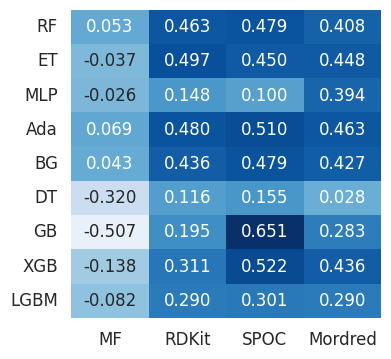

In [5]:
fig = plt.figure(figsize=(4,4))
sns.set(font_scale=1)
sns.heatmap(r2_map.T,annot=True,fmt='.3f',xticklabels=desc_names,yticklabels=model_names,cmap='Blues',cbar=False,vmin=-0.6,vmax=r2_map.max())

plt.xticks(fontsize=12)
plt.yticks(fontsize=12,rotation=0)
plt.show()
print()

In [10]:
other_desc_screen_r2_without_hyper_opt = pd.read_csv("../results/model_tsdesc_other_desc_screen_r2.csv")
other_desc_screen_r2_without_hyper_opt

,Unnamed: 0,MF,RDKit,SPOC,Mordred
0,RF,-0.061951,0.449140,0.466524,0.349352
1,ET,-0.100120,0.405652,0.363180,0.240518
2,MLP,-0.110475,0.156580,0.001921,-0.019427
3,Ada,-0.337111,0.150126,0.435352,0.244151
4,BG,-0.085915,0.341772,0.439361,0.385626
5,DT,-1.738333,-1.156437,-0.988711,-0.079269
6,GB,-0.121112,0.503226,0.611665,0.307568
7,XGB,-0.068555,0.212272,0.426819,0.192917
8,LGBM,-0.111045,0.280534,0.263348,0.262078


In [18]:
((r2_map.T - other_desc_screen_r2_without_hyper_opt.to_numpy()[:,1:])>0).sum()

31

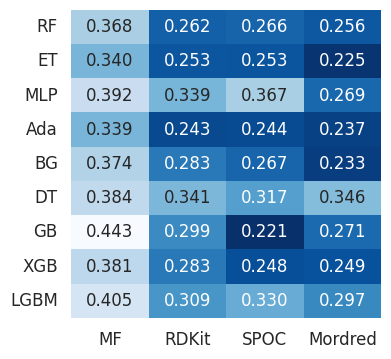

In [5]:
fig = plt.figure(figsize=(4,4))
sns.set(font_scale=1)
sns.heatmap(mae_map.T,annot=True,fmt='.3f',xticklabels=desc_names,yticklabels=model_names,cmap='Blues_r',cbar=False,)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12,rotation=0)
plt.show()
print()

In [19]:
ferr_lig_results = glob.glob("./results/ferr_lig*.npy") + glob.glob("./results/SPOC_*.npy")
desc_name_map = {'ACSF':"ACSF", 'MBTR':"MBTR", 'Mordred':"Mordred", 'MorganFingerprints':"MF", "RDKit":"RDKit", "SOAP":"SOAP","SPOC":"SPOC","TS":"TS"}

In [20]:
results_map = {}
for file in ferr_lig_results:
    res = np.load(file,allow_pickle=True).item()
    fn = os.path.basename(file)[:-4]
    if fn.startswith("SPOC"):
        model = fn.split("_")[1]
        results_map[('TS',model_name_map[model])] = res
    else:
        desc = fn.split("_")[2]
        model = fn.split("_")[3]
        results_map[(desc_name_map[desc],model_name_map[model])] = res

In [8]:
results_map

{('RDKit', 'XGB'): {'r2': 0.3011624626589191, 'mae': 0.2953535693752319},
 ('MF', 'ET'): {'r2': 0.4979857757944415, 'mae': 0.23644452315090403},
 ('ACSF', 'GB'): {'r2': 0.47144525019161787, 'mae': 0.27499860229579354},
 ('ACSF', 'MLP'): {'r2': 0.2712022387185784, 'mae': 0.3094029267539501},
 ('RDKit', 'RF'): {'r2': 0.4401621939404472, 'mae': 0.265877517743781},
 ('RDKit', 'BG'): {'r2': 0.42087869041043413, 'mae': 0.26315841276028484},
 ('Mordred', 'GB'): {'r2': 0.4515607487983636, 'mae': 0.24967617131803035},
 ('MF', 'MLP'): {'r2': 0.1498989169695012, 'mae': 0.3314811589242939},
 ('MF', 'GB'): {'r2': 0.5913862680604778, 'mae': 0.22637386133952417},
 ('SOAP', 'ET'): {'r2': 0.5983974810878795, 'mae': 0.2234739419705795},
 ('SOAP', 'XGB'): {'r2': 0.4252327635309512, 'mae': 0.27446247232558435},
 ('SOAP', 'GB'): {'r2': 0.3868054687632485, 'mae': 0.2700971925080844},
 ('ACSF', 'XGB'): {'r2': 0.4400348112246375, 'mae': 0.2711236712870723},
 ('MBTR', 'XGB'): {'r2': 0.22464824804444794, 'mae':

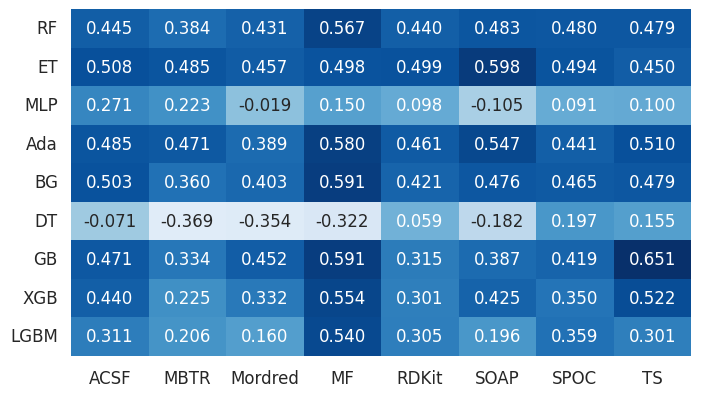

In [26]:
mae_map = np.zeros((len(desc_name_map),len(model_name_map)))
r2_map = np.zeros((len(desc_name_map),len(model_name_map)))
model_names = model_name_map.values()
desc_names = desc_name_map.values()
for i,m in enumerate(model_names):
    for j,d in enumerate(desc_names):
        mae_map[j,i] = results_map[(d,m)]["mae"]
        r2_map[j,i] = results_map[(d,m)]["r2"]

fig = plt.figure(figsize=(8,4.5))

sns.set(font_scale=1)
sns.heatmap(r2_map.T,annot=True,fmt='.3f',xticklabels=desc_names,yticklabels=model_names,cmap='Blues',cbar=False,vmin=-0.5,vmax=r2_map.max()) # ,vmin=-1,vmax=0.65
plt.xticks(rotation=0,fontsize=12)
plt.yticks(rotation=0,fontsize=12)
plt.show()
print()

In [23]:
ferr_lig_r2_without_hyper_opt = pd.read_csv("../results/model_tot_desc_screen_r2.csv")
ferr_lig_r2_without_hyper_opt

,Unnamed: 0,ACSF,MBTR,Mordred,MF,RDKit,SOAP,SPOC,TS
0,RF,0.412345,0.352870,0.411117,0.541408,0.399576,0.391438,0.446580,0.466524
1,ET,0.469410,0.416780,0.429239,0.466558,0.484230,0.493464,0.433704,0.363180
2,MLP,0.126034,0.075114,-0.254020,0.215490,-0.058435,0.053736,0.043793,0.001921
3,Ada,0.351304,0.327416,0.137469,0.457432,0.400858,0.199621,0.405363,0.435352
4,BG,0.423779,0.354718,0.431523,0.577132,0.366724,0.377452,0.346645,0.439361
5,DT,-0.795906,-1.367691,-0.266391,-0.824851,-0.661508,-0.704760,-0.236400,-0.988711
6,GB,0.468196,0.138550,0.448435,0.427764,0.534707,0.344901,0.516353,0.611665
7,XGB,0.269578,0.234682,0.444061,0.426860,0.365437,0.450197,0.460723,0.426819
8,LGBM,0.250979,0.010182,0.160182,0.411110,0.176959,0.183946,0.249138,0.263348


In [31]:
(r2_map.T - ferr_lig_r2_without_hyper_opt.to_numpy()[:,1:]>0).sum()

60

In [33]:
r2_map.shape

(8, 9)

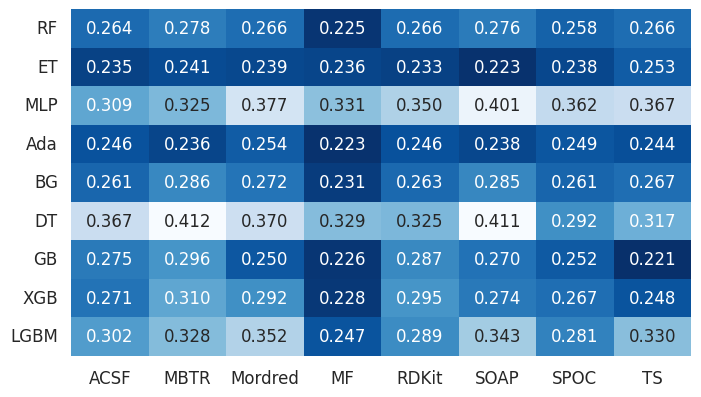

In [11]:
fig = plt.figure(figsize=(8,4.5))
sns.set(font_scale=1)
sns.heatmap(mae_map.T,annot=True,fmt='.3f',xticklabels=desc_names,yticklabels=model_names,cmap='Blues_r',cbar=False,vmin=mae_map.min(),vmax=mae_map.max()) # ,vmin=-1,vmax=0.65
plt.xticks(rotation=0,fontsize=12)
plt.yticks(rotation=0,fontsize=12)
plt.show()
print()